# Descriptive statistics in Python

This notebook goes with [chapter 1 of the statistics book](/statistics/01-descriptive-statistics). We compute the mean, median, variance and standard deviation of a small dataset, first by hand and then with NumPy and pandas.

**Try it:** change the numbers in `scores` and re-run all cells.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores = np.array([4, 7, 7, 9, 13])

## By hand

The sample mean is $\bar{x} = \frac{1}{n}\sum x_i$ and the sample variance is $s^2 = \frac{1}{n-1}\sum (x_i - \bar{x})^2$.

In [2]:
n = len(scores)
mean = scores.sum() / n
variance = ((scores - mean) ** 2).sum() / (n - 1)

print(f"mean     = {mean}")
print(f"variance = {variance}")
print(f"std      = {variance ** 0.5:.3f}")

mean     = 8.0
variance = 11.0
std      = 3.317


## With NumPy

Careful: `np.var` and `np.std` divide by $n$ unless you pass `ddof=1`.

In [3]:
print("median        :", np.median(scores))
print("var (ddof=0)  :", np.var(scores))
print("var (ddof=1)  :", np.var(scores, ddof=1))
print("std (ddof=1)  :", round(np.std(scores, ddof=1), 3))

median        : 7.0
var (ddof=0)  : 8.8
var (ddof=1)  : 11.0
std (ddof=1)  : 3.317


## With pandas

`describe()` gives a full summary in one call. pandas uses $n - 1$ by default.

In [4]:
df = pd.DataFrame({"score": scores})
df.describe().round(2)

,score
count,5.00
mean,8.00
std,3.32
min,4.00
25%,7.00
50%,7.00
75%,9.00
max,13.00


## A quick picture

A histogram shows the shape of the data. The dashed line marks the mean, the solid line the median.

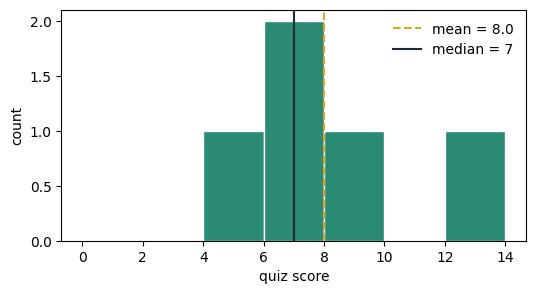

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(scores, bins=range(0, 16, 2), edgecolor="white", color="#2a8a73")
ax.axvline(scores.mean(), linestyle="--", color="#e0a526", label=f"mean = {scores.mean():.1f}")
ax.axvline(np.median(scores), color="#1f2937", label=f"median = {np.median(scores):.0f}")
ax.set_xlabel("quiz score")
ax.set_ylabel("count")
ax.legend(frameon=False)
plt.show()

## Exercise

Replace `13` with `130` in `scores` and run the notebook again. Which numbers change a lot, and which barely move?